In [5]:
import pandas as pd

Saved 20 scenarios × 24 hours to wind_scenarios_DK2.csv
MW range: 0.1 – 459.2

  SELECTED SCENARIO DATES — match these in Nord Pool price data
  #    Season     Date           Weekday        Avg CF    Avg MW
------------------------------------------------------------
  1    Winter     2023-02-06     Monday          0.049     24.4 MW
  2    Winter     2023-02-07     Tuesday         0.122     61.0 MW
  3    Winter     2023-02-08     Wednesday       0.245    122.6 MW
  4    Winter     2023-02-09     Thursday        0.475    237.4 MW
  5    Winter     2023-02-10     Friday          0.464    232.1 MW

  6    Spring     2023-05-08     Monday          0.386    193.2 MW
  7    Spring     2023-05-09     Tuesday         0.540    269.8 MW
  8    Spring     2023-05-10     Wednesday       0.385    192.4 MW
  9    Spring     2023-05-11     Thursday        0.129     64.3 MW
  10   Spring     2023-05-12     Friday          0.188     93.9 MW

  11   Summer     2023-08-07     Monday          0.857    4

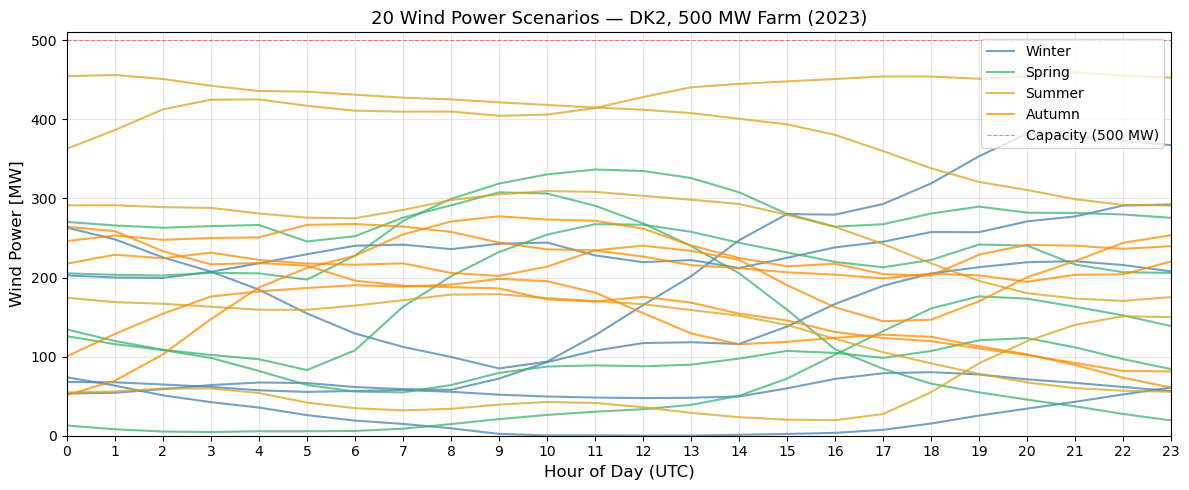

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# Configuration
# =============================================================================
DATA_PATH = 'ninja-wind-country-DK-current_onshore-merra2.csv'
OUTPUT_CSV = 'wind_scenarios_DK2.csv'
OUTPUT_PLOT = 'wind_scenarios_plot.pdf'
CAPACITY_MW = 500

# 20 scenarios: 5 days per season (Mon–Fri of 2nd full week of middle month)
# Middle months: Feb (Winter), May (Spring), Aug (Summer), Nov (Autumn)
SCENARIO_DAYS = [
    # Winter: Feb 2023
    '2023-02-06', '2023-02-07', '2023-02-08', '2023-02-09', '2023-02-10',
    # Spring: May 2023
    '2023-05-08', '2023-05-09', '2023-05-10', '2023-05-11', '2023-05-12',
    # Summer: Aug 2023
    '2023-08-07', '2023-08-08', '2023-08-09', '2023-08-10', '2023-08-11',
    # Autumn: Nov 2023
    '2023-11-06', '2023-11-07', '2023-11-08', '2023-11-09', '2023-11-10',
]
SEASONS = ['Winter'] * 5 + ['Spring'] * 5 + ['Summer'] * 5 + ['Autumn'] * 5

# =============================================================================
# Load data
# =============================================================================
df = pd.read_csv(DATA_PATH, skiprows=3)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.set_index('time')

# =============================================================================
# Extract 24-hour profiles for each scenario day (DK02 column)
# =============================================================================
scenarios = {}
for day, season in zip(SCENARIO_DAYS, SEASONS):
    start = pd.Timestamp(day, tz='UTC')
    end = start + pd.Timedelta(hours=23)
    cf = df.loc[start:end, 'DK02'].values
    assert len(cf) == 24, f"Expected 24 hours for {day}, got {len(cf)}"
    scenarios[f"{season}_{day}"] = cf * CAPACITY_MW

scen_df = pd.DataFrame(scenarios, index=range(24))
scen_df.index.name = 'hour'

# =============================================================================
# Save to CSV
# =============================================================================
scen_df.to_csv(OUTPUT_CSV)
print(f"Saved {scen_df.shape[1]} scenarios × {scen_df.shape[0]} hours to {OUTPUT_CSV}")
print(f"MW range: {scen_df.values.min():.1f} – {scen_df.values.max():.1f}")

# =============================================================================
# Summary table of selected dates (for matching price data)
# =============================================================================
print("\n" + "=" * 60)
print("  SELECTED SCENARIO DATES — match these in Nord Pool price data")
print("=" * 60)
print(f"  {'#':<4} {'Season':<10} {'Date':<14} {'Weekday':<12} {'Avg CF':>8}  {'Avg MW':>8}")
print("-" * 60)
for i, (day, season) in enumerate(zip(SCENARIO_DAYS, SEASONS)):
    col = f"{season}_{day}"
    avg_cf = scen_df[col].mean() / CAPACITY_MW
    avg_mw = scen_df[col].mean()
    weekday = pd.Timestamp(day).day_name()
    print(f"  {i+1:<4} {season:<10} {day:<14} {weekday:<12} {avg_cf:>8.3f}  {avg_mw:>7.1f} MW")
    if (i + 1) % 5 == 0 and i + 1 < len(SCENARIO_DAYS):
        print()
print("=" * 60)

# =============================================================================
# Plot
# =============================================================================
season_colors = {
    'Winter': 'steelblue',
    'Spring': 'mediumseagreen',
    'Summer': 'goldenrod',
    'Autumn': 'darkorange',
}
season_labels = {s: False for s in season_colors}

fig, ax = plt.subplots(figsize=(12, 5))
for col in scen_df.columns:
    season = col.split('_')[0]
    color = season_colors[season]
    label = season if not season_labels[season] else None
    ax.plot(scen_df.index, scen_df[col], color=color, alpha=0.75, linewidth=1.5, label=label)
    season_labels[season] = True

ax.axhline(500, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Capacity (500 MW)')
ax.set_xlabel('Hour of Day (UTC)', fontsize=12)
ax.set_ylabel('Wind Power [MW]', fontsize=12)
ax.set_title('20 Wind Power Scenarios — DK2, 500 MW Farm (2023)', fontsize=13)
ax.set_xticks(range(24))
ax.set_xlim(0, 23)
ax.set_ylim(0, 510)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=150)
print(f"Plot saved to {OUTPUT_PLOT}")
plt.show()

Saved 20 scenarios × 24 hours to price_scenarios_DK2.csv

  PRICE SCENARIOS — DK2 Day-Ahead (EUR/MWh), CET, 2023
  #    Season     Date               Min    Mean     Max
-----------------------------------------------------------------
  1    Winter     2023-02-06      140.10  172.66  213.50
  2    Winter     2023-02-07      131.63  171.86  245.60
  3    Winter     2023-02-08       13.93  121.73  216.19
  4    Winter     2023-02-09        7.33   21.73   29.45
  5    Winter     2023-02-10       17.84   51.94  142.76

  6    Spring     2023-05-08       29.33   68.68  116.58
  7    Spring     2023-05-09        0.01   20.12   57.78
  8    Spring     2023-05-10        0.00   10.26   35.55
  9    Spring     2023-05-11       14.56   81.27  167.78
  10   Spring     2023-05-12       37.23   84.04  137.98

  11   Summer     2023-08-07       -1.14    1.93   21.21
  12   Summer     2023-08-08      -11.60   -3.95   -0.13
  13   Summer     2023-08-09       -1.18   10.75   53.89
  14   Summer     202

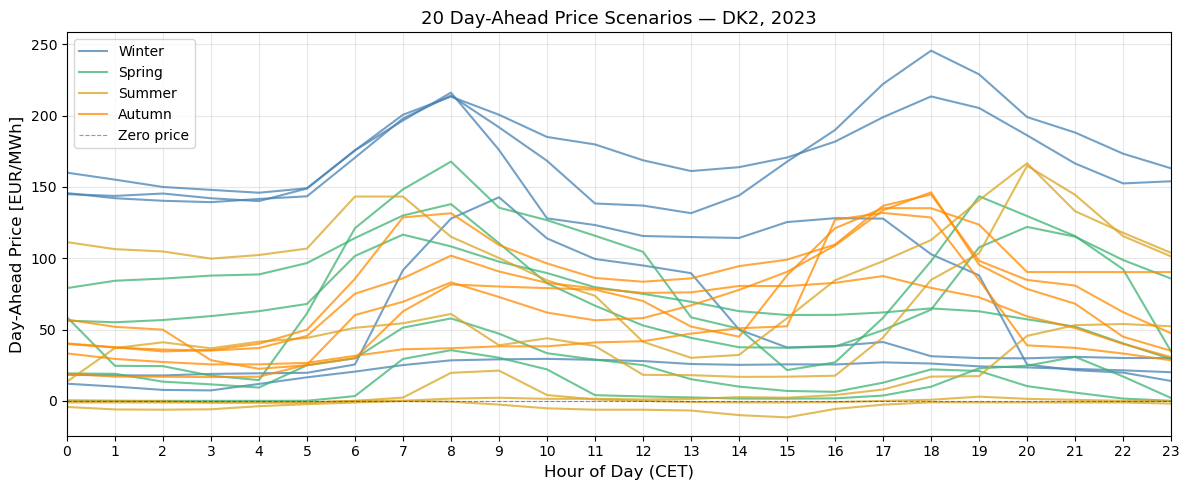

In [7]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt

# =============================================================================
# Configuration
# =============================================================================
DATA_PATH = 'GUI_ENERGY_PRICES_202212312300-202312312300.csv'
OUTPUT_CSV = 'price_scenarios_DK2.csv'
OUTPUT_PLOT = 'price_scenarios_plot.pdf'

# Must match the dates used in wind_scenarios.py
SCENARIO_DAYS = [
    # Winter: Feb 2023
    '2023-02-06', '2023-02-07', '2023-02-08', '2023-02-09', '2023-02-10',
    # Spring: May 2023
    '2023-05-08', '2023-05-09', '2023-05-10', '2023-05-11', '2023-05-12',
    # Summer: Aug 2023
    '2023-08-07', '2023-08-08', '2023-08-09', '2023-08-10', '2023-08-11',
    # Autumn: Nov 2023
    '2023-11-06', '2023-11-07', '2023-11-08', '2023-11-09', '2023-11-10',
]
SEASONS = ['Winter'] * 5 + ['Spring'] * 5 + ['Summer'] * 5 + ['Autumn'] * 5

# =============================================================================
# Load and parse
# =============================================================================
df = pd.read_csv(DATA_PATH)

# ENTSO-E timestamps look like "06/02/2023 00:00:00 (CET)" — extract numerics only
raw = df['MTU (CET/CEST)'].str.split(' - ').str[0]
extracted = raw.str.extract(r'(\d{2}/\d{2}/\d{4} \d{2}:\d{2}:\d{2})')
df['time'] = pd.to_datetime(extracted[0], format='%d/%m/%Y %H:%M:%S')
df['price'] = pd.to_numeric(df['Day-ahead Price (EUR/MWh)'], errors='coerce')
df['date'] = df['time'].dt.date
df['hour'] = df['time'].dt.hour

# =============================================================================
# Extract 24-hour price profiles for each scenario day
# =============================================================================
scenarios = {}
for day, season in zip(SCENARIO_DAYS, SEASONS):
    d = datetime.date.fromisoformat(day)
    day_df = df[df['date'] == d].sort_values('hour')
    prices = day_df['price'].values
    assert len(prices) == 24, f"{day}: expected 24 hours, got {len(prices)}"
    scenarios[f"{season}_{day}"] = prices

price_df = pd.DataFrame(scenarios, index=range(24))
price_df.index.name = 'hour'

# =============================================================================
# Save to CSV
# =============================================================================
price_df.to_csv(OUTPUT_CSV)
print(f"Saved {price_df.shape[1]} scenarios × {price_df.shape[0]} hours to {OUTPUT_CSV}")

# =============================================================================
# Summary table
# =============================================================================
print("\n" + "=" * 65)
print("  PRICE SCENARIOS — DK2 Day-Ahead (EUR/MWh), CET, 2023")
print("=" * 65)
print(f"  {'#':<4} {'Season':<10} {'Date':<14} {'Min':>7} {'Mean':>7} {'Max':>7}")
print("-" * 65)
for i, (day, season) in enumerate(zip(SCENARIO_DAYS, SEASONS)):
    col = f"{season}_{day}"
    mn  = price_df[col].min()
    avg = price_df[col].mean()
    mx  = price_df[col].max()
    print(f"  {i+1:<4} {season:<10} {day:<14} {mn:>7.2f} {avg:>7.2f} {mx:>7.2f}")
    if (i + 1) % 5 == 0 and i + 1 < len(SCENARIO_DAYS):
        print()
print("=" * 65)

# =============================================================================
# Plot
# =============================================================================
season_colors = {
    'Winter': 'steelblue',
    'Spring': 'mediumseagreen',
    'Summer': 'goldenrod',
    'Autumn': 'darkorange',
}
season_labels = {s: False for s in season_colors}

fig, ax = plt.subplots(figsize=(12, 5))
for col in price_df.columns:
    season = col.split('_')[0]
    color = season_colors[season]
    label = season if not season_labels[season] else None
    ax.plot(price_df.index, price_df[col], color=color, alpha=0.75, linewidth=1.5, label=label)
    season_labels[season] = True

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4, label='Zero price')
ax.set_xlabel('Hour of Day (CET)', fontsize=12)
ax.set_ylabel('Day-Ahead Price [EUR/MWh]', fontsize=12)
ax.set_title('20 Day-Ahead Price Scenarios — DK2, 2023', fontsize=13)
ax.set_xticks(range(24))
ax.set_xlim(0, 23)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=150)
print(f"\nPlot saved to {OUTPUT_PLOT}")
plt.show()

Empirical probability of deficit (SI=1) per hour:
hour_index
0     0.2493
1     0.2740
2     0.2548
3     0.2384
4     0.2356
5     0.1753
6     0.2219
7     0.2712
8     0.2521
9     0.2712
10    0.3425
11    0.3397
12    0.3452
13    0.2904
14    0.2548
15    0.2959
16    0.3041
17    0.2986
18    0.2904
19    0.2685
20    0.2192
21    0.2438
22    0.2603
23    0.2329

SI scenarios (rows=scenarios, cols=hours):
               h00  h01  h02  h03  h04  h05  h06  h07  h08  h09  h10  h11  h12  h13  h14  h15  h16  h17  h18  h19  h20  h21  h22  h23
scenario                                                                                                                             
SI_scenario_1    1    0    0    0    0    0    1    0    0    0    0    1    1    1    0    0    0    0    1    0    0    0    0    0
SI_scenario_2    0    1    0    1    0    0    0    0    0    0    1    1    0    0    0    0    0    0    0    0    0    0    0    0
SI_scenario_3    1    1    0    0    1    1    

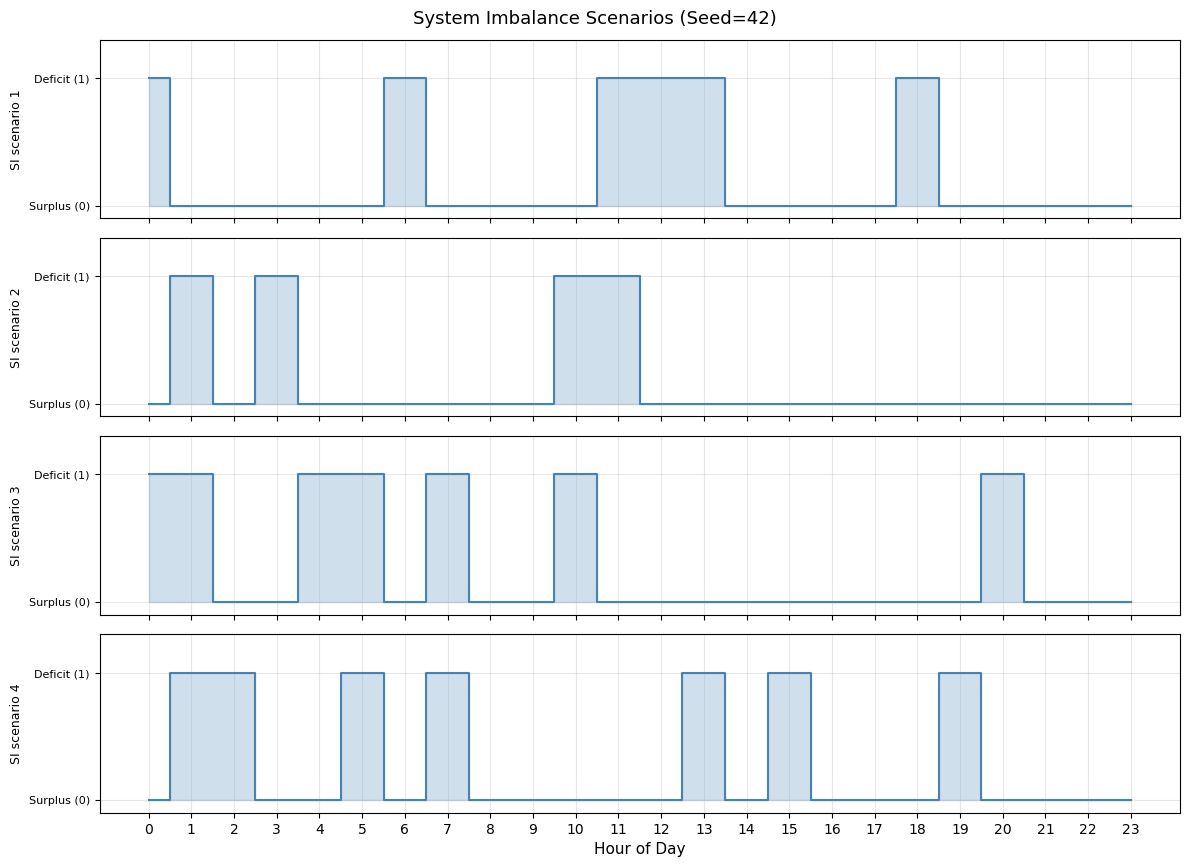

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# Configuration
# =============================================================================
ENERGY_REPORT_PATH = 'EnergyReport.csv'
PRICE_SCENARIOS_PATH = 'price_scenarios_DK2.csv'
OUTPUT_SI_CSV   = 'si_scenarios.csv'
OUTPUT_BP_CSV   = 'bp_scenarios.csv'
OUTPUT_PLOT     = 'imbalance_scenarios_plot.pdf'

N_SI_SCENARIOS = 4
RANDOM_SEED    = 42          # Fix seed for reproducibility

# =============================================================================
# Step 1 — Compute empirical hourly probabilities of deficit (SI = 1)
# SI = 1 if ImbalancePrice > DayAheadPrice (system in supply deficit)
# =============================================================================
df = pd.read_csv(ENERGY_REPORT_PATH)
df['HourDK'] = pd.to_datetime(df['HourDK'])
df['hour_index'] = df['HourDK'].dt.hour
df['SI_historical'] = (df['ImbalancePriceEURDK2'] > df['DK2_EUR/MWh']).astype(int)

hourly_probs = df.groupby('hour_index')['SI_historical'].mean()

print("Empirical probability of deficit (SI=1) per hour:")
print(hourly_probs.round(4).to_string())

# =============================================================================
# Step 2 — Generate SI scenarios using empirical Bernoulli distribution
# =============================================================================
rng = np.random.default_rng(RANDOM_SEED)   # reproducible RNG

si_matrix = np.zeros((N_SI_SCENARIOS, 24), dtype=int)
for h in range(24):
    si_matrix[:, h] = rng.binomial(1, hourly_probs[h], N_SI_SCENARIOS)

si_df = pd.DataFrame(
    si_matrix,
    index=[f"SI_scenario_{i+1}" for i in range(N_SI_SCENARIOS)],
    columns=[f"h{h:02d}" for h in range(24)]
)
si_df.index.name = 'scenario'
si_df.to_csv(OUTPUT_SI_CSV)

print("\nSI scenarios (rows=scenarios, cols=hours):")
print(si_df.to_string())

# =============================================================================
# Step 3 — Load DA price scenarios and compute balancing prices
# BP = 1.25 * DA if SI=1 (deficit), BP = 0.85 * DA if SI=0 (surplus)
# Combined scenarios: 20 DA price scenarios x 4 SI scenarios = 80 total
# =============================================================================
price_df = pd.read_csv(PRICE_SCENARIOS_PATH, index_col='hour')

bp_records = {}
for da_col in price_df.columns:
    da_prices = price_df[da_col].values          # shape (24,)
    for si_idx in range(N_SI_SCENARIOS):
        si_path = si_matrix[si_idx]              # shape (24,)
        bp = np.where(si_path == 1, da_prices * 1.25, da_prices * 0.85)
        label = f"{da_col}__SI{si_idx+1}"
        bp_records[label] = bp

bp_df = pd.DataFrame(bp_records, index=range(24))
bp_df.index.name = 'hour'
bp_df.to_csv(OUTPUT_BP_CSV)

print(f"\nBalancing price scenarios saved: {bp_df.shape[1]} combined scenarios")
print(f"  ({price_df.shape[1]} DA scenarios × {N_SI_SCENARIOS} SI scenarios)")

# =============================================================================
# Step 4 — Summary table
# =============================================================================
print("\n" + "=" * 65)
print("  SI SCENARIO SUMMARY")
print("=" * 65)
print(f"  {'Scenario':<15} {'Hours SI=1':>10} {'Hours SI=0':>10}")
print("-" * 65)
for i in range(N_SI_SCENARIOS):
    n_deficit = si_matrix[i].sum()
    print(f"  SI_scenario_{i+1:<3}  {n_deficit:>10}  {24 - n_deficit:>10}")
print("=" * 65)

# =============================================================================
# Step 5 — Plot SI scenarios
# =============================================================================
fig, axes = plt.subplots(N_SI_SCENARIOS, 1, figsize=(12, 2.2 * N_SI_SCENARIOS), sharex=True)
for i, ax in enumerate(axes):
    ax.step(range(24), si_matrix[i], where='mid', color='steelblue', linewidth=1.5)
    ax.fill_between(range(24), si_matrix[i], step='mid', alpha=0.25, color='steelblue')
    ax.set_ylabel(f"SI scenario {i+1}", fontsize=9)
    ax.set_ylim(-0.1, 1.3)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Surplus (0)', 'Deficit (1)'], fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Hour of Day', fontsize=11)
axes[-1].set_xticks(range(24))
fig.suptitle('System Imbalance Scenarios (Seed=42)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=150)
print(f"\nPlot saved to {OUTPUT_PLOT}")
plt.show()